In [1]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\ASHOKA
[nltk_data]     MS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
import os
import json
from nltk.tokenize import sent_tokenize

# 🔹 INPUT FOLDER (your ASR json files)
input_folder = r"C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json"

# 🔹 OUTPUT FOLDER
output_folder = os.path.join(input_folder, "sentence_split")
os.makedirs(output_folder, exist_ok=True)


def split_segments(data):
    results = []

    # ✅ Support both formats:
    # 1️⃣ {"segments": [...]}
    # 2️⃣ [ {...}, {...} ]
    if isinstance(data, dict) and "segments" in data:
        segments = data["segments"]
    else:
        segments = data

    for seg in segments:
        text = seg.get("text", "").strip()
        start = float(seg.get("start", 0))
        end = float(seg.get("end", start))

        if not text:
            continue

        # split into sentences
        sentences = sent_tokenize(text)

        # if only one sentence → keep timestamps
        if len(sentences) == 1:
            results.append({
                "sentence": sentences[0],
                "start": start,
                "end": end
            })

        else:
            # divide time evenly among sentences
            duration = end - start
            step = duration / len(sentences)

            for i, sent in enumerate(sentences):
                results.append({
                    "sentence": sent,
                    "start": round(start + i * step, 3),
                    "end": round(start + (i + 1) * step, 3)
                })

    return results


# 🔹 PROCESS ALL FILES
for file in os.listdir(input_folder):
    if file.endswith(".json"):
        path = os.path.join(input_folder, file)

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        output = split_segments(data)

        # save output
        out_path = os.path.join(output_folder, file)
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(output, f, indent=2, ensure_ascii=False)

        print(f"✅ Processed: {file}")

print("\n🎉 DONE! Sentence-level files saved in:")
print(output_folder)

✅ Processed: audio1.json
✅ Processed: audio10.json
✅ Processed: audio11.json
✅ Processed: audio12.json
✅ Processed: audio13.json
✅ Processed: audio14.json
✅ Processed: audio15.json
✅ Processed: audio16.json
✅ Processed: audio17.json
✅ Processed: audio2.json
✅ Processed: audio3.json
✅ Processed: audio4.json
✅ Processed: audio5.json
✅ Processed: audio6.json
✅ Processed: audio7.json
✅ Processed: audio8.json
✅ Processed: audio9.json

🎉 DONE! Sentence-level files saved in:
C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json\sentence_split


In [1]:
import os
import json
from sentence_transformers import SentenceTransformer

# 📁 Folder with sentence-level JSON files
input_folder = r"C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json\sentence_split"

# 📁 Output folder
output_folder = os.path.join(input_folder, "embeddings")
os.makedirs(output_folder, exist_ok=True)

# ✅ Load SBERT model (fast & accurate)
model = SentenceTransformer('all-MiniLM-L6-v2')

def generate_embeddings(data):
    sentences = [item["sentence"] for item in data]

    # create embeddings
    vectors = model.encode(sentences)

    results = []
    for item, vec in zip(data, vectors):
        results.append({
            "sentence": item["sentence"],
            "start": item["start"],
            "end": item["end"],
            "embedding": vec.tolist()   # convert numpy → list for JSON
        })

    return results


# 🔹 Process all files
for file in os.listdir(input_folder):
    if file.endswith(".json"):
        path = os.path.join(input_folder, file)

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        output = generate_embeddings(data)

        out_path = os.path.join(output_folder, file)
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(output, f)

        print(f"✅ Embedded: {file}")

print("\n🎉 Embeddings generated successfully!")

C:\Users\ASHOKA MS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████| 103/103 [00:01<00:00, 96.33it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedded: audio1.json
✅ Embedded: audio10.json
✅ Embedded: audio11.json
✅ Embedded: audio12.json
✅ Embedded: audio13.json
✅ Embedded: audio14.json
✅ Embedded: audio15.json
✅ Embedded: audio16.json
✅ Embedded: audio17.json
✅ Embedded: audio2.json
✅ Embedded: audio3.json
✅ Embedded: audio4.json
✅ Embedded: audio5.json
✅ Embedded: audio6.json
✅ Embedded: audio7.json
✅ Embedded: audio8.json
✅ Embedded: audio9.json

🎉 Embeddings generated successfully!


In [1]:
import os
import json
from sklearn.metrics.pairwise import cosine_similarity

# 📁 Folder containing embedding JSON files
input_folder = r"C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json\sentence_split\embeddings"

# 📁 Output folder
output_folder = os.path.join(input_folder, "similarity")
os.makedirs(output_folder, exist_ok=True)


def compute_similarity(data):
    similarities = []

    for i in range(len(data) - 1):
        vec1 = data[i]["embedding"]
        vec2 = data[i+1]["embedding"]

        sim = cosine_similarity([vec1], [vec2])[0][0]

        similarities.append({
            "sentence_1": data[i]["sentence"],
            "sentence_2": data[i+1]["sentence"],
            "similarity": float(sim),
            "end_time": data[i]["end"]   # where transition occurs
        })

    return similarities


# 🔹 Process all files
for file in os.listdir(input_folder):
    if file.endswith(".json"):
        path = os.path.join(input_folder, file)

        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        output = compute_similarity(data)

        out_path = os.path.join(output_folder, file)
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(output, f, indent=2)

        print(f"✅ Similarity computed: {file}")

print("\n🎉 Similarity curves generated!")

✅ Similarity computed: audio1.json
✅ Similarity computed: audio10.json
✅ Similarity computed: audio11.json
✅ Similarity computed: audio12.json
✅ Similarity computed: audio13.json
✅ Similarity computed: audio14.json
✅ Similarity computed: audio15.json
✅ Similarity computed: audio16.json
✅ Similarity computed: audio17.json
✅ Similarity computed: audio2.json
✅ Similarity computed: audio3.json
✅ Similarity computed: audio4.json
✅ Similarity computed: audio5.json
✅ Similarity computed: audio6.json
✅ Similarity computed: audio7.json
✅ Similarity computed: audio8.json
✅ Similarity computed: audio9.json

🎉 Similarity curves generated!


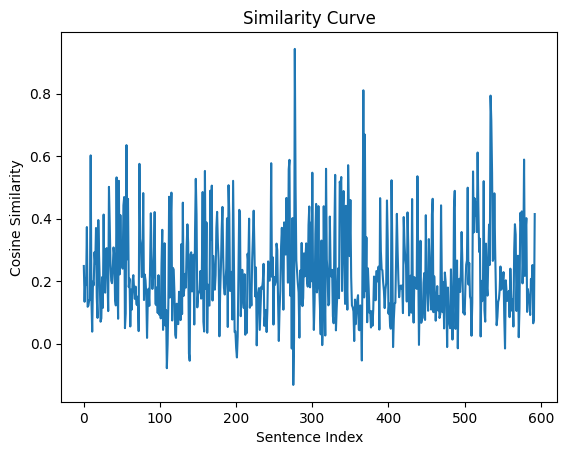

In [2]:
import matplotlib.pyplot as plt

values = [s["similarity"] for s in output]

plt.plot(values)
plt.title("Similarity Curve")
plt.xlabel("Sentence Index")
plt.ylabel("Cosine Similarity")
plt.show()

In [3]:
def boundary_metrics(true_boundaries, predicted_boundaries, tolerance=1):
    """
    tolerance = allow ±1 sentence difference
    """

    true_set = set(true_boundaries)
    pred_set = set(predicted_boundaries)

    matched = 0

    for p in pred_set:
        for t in true_set:
            if abs(p - t) <= tolerance:
                matched += 1
                break

    precision = matched / len(pred_set) if pred_set else 0
    recall = matched / len(true_set) if true_set else 0

    return precision, recall

In [4]:
true_boundaries = [3, 7]
predicted_boundaries = [2, 7, 11]

precision, recall = boundary_metrics(true_boundaries, predicted_boundaries)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.6666666666666666
Recall: 1.0


In [5]:
import json

# 📌 INPUT FILE (sentence split file)
input_file = r"C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json\sentence_split\audio1.json"

# 📌 OUTPUT FILE
output_file = r"C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json\final_segments_E01.json"

# predicted boundaries (example)
boundaries = [2]   # new topic starts at sentence index 2

EPISODE_ID = "E01"
MODEL_NAME = "MiniLM-L6-v2"


def create_segments(sentences, boundaries):
    segments = []
    start_idx = 0
    segment_id = 1

    # add final boundary
    boundaries.append(len(sentences))

    for boundary in boundaries:
        segment_sentences = sentences[start_idx:boundary]

        if not segment_sentences:
            continue

        segment_text = " ".join(s["sentence"] for s in segment_sentences)

        segments.append({
            "segment_id": segment_id,
            "start_time": segment_sentences[0]["start"],
            "end_time": segment_sentences[-1]["end"],
            "text": segment_text,
            "embedding_model": MODEL_NAME
        })

        segment_id += 1
        start_idx = boundary

    return segments


# load sentences
with open(input_file, "r", encoding="utf-8") as f:
    sentences = json.load(f)

segments = create_segments(sentences, boundaries)

final_output = {
    "episode_id": EPISODE_ID,
    "segments": segments
}

# save file
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(final_output, f, indent=2, ensure_ascii=False)

print("✅ Segmentation file created!")

✅ Segmentation file created!


In [6]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\ASHOKA
[nltk_data]     MS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
import os
import json
import numpy as np
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 📁 INPUT FOLDER (ASR transcripts)
INPUT_FOLDER = r"C:\Users\ASHOKA MS\Desktop\audio transcribe\datasets\asr_json"

# 📁 OUTPUT FOLDER
OUTPUT_FOLDER = os.path.join(INPUT_FOLDER, "final_segments")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

MODEL_NAME = "all-MiniLM-L6-v2"

print("Loading MiniLM model...")
model = SentenceTransformer(MODEL_NAME)


# --------------------------------------------------
# STEP 1: Sentence Splitting
# --------------------------------------------------
def split_sentences(data):

    if isinstance(data, dict) and "segments" in data:
        segments = data["segments"]
    else:
        segments = data

    sentences = []

    for seg in segments:
        text = seg.get("text", "").strip()
        start = float(seg.get("start", 0))
        end = float(seg.get("end", start))

        if not text:
            continue

        sents = sent_tokenize(text)

        if len(sents) == 1:
            sentences.append({
                "sentence": sents[0],
                "start": start,
                "end": end
            })
        else:
            duration = end - start
            step = duration / len(sents)

            for i, s in enumerate(sents):
                sentences.append({
                    "sentence": s,
                    "start": round(start + i * step, 3),
                    "end": round(start + (i + 1) * step, 3)
                })

    return sentences


# --------------------------------------------------
# STEP 2: Embeddings
# --------------------------------------------------
def generate_embeddings(sentences):
    texts = [s["sentence"] for s in sentences]
    vectors = model.encode(texts)

    for i, vec in enumerate(vectors):
        sentences[i]["embedding"] = vec

    return sentences


# --------------------------------------------------
# STEP 3: Similarity Curve
# --------------------------------------------------
def compute_similarity(sentences):
    sims = []

    for i in range(len(sentences) - 1):
        sim = cosine_similarity(
            [sentences[i]["embedding"]],
            [sentences[i+1]["embedding"]]
        )[0][0]

        sims.append(sim)

    return sims


# --------------------------------------------------
# STEP 4: Boundary Detection
# --------------------------------------------------
def detect_boundaries(similarities, threshold=0.65):
    """
    detect topic shifts when similarity drops below threshold
    """
    boundaries = []

    for i, sim in enumerate(similarities):
        if sim < threshold:
            boundaries.append(i + 1)

    return boundaries


# --------------------------------------------------
# STEP 5: Segment Grouping
# --------------------------------------------------
def group_segments(sentences, boundaries):

    segments = []
    start_idx = 0
    seg_id = 1

    boundaries.append(len(sentences))

    for boundary in boundaries:
        chunk = sentences[start_idx:boundary]

        if not chunk:
            continue

        segments.append({
            "segment_id": seg_id,
            "start_time": chunk[0]["start"],
            "end_time": chunk[-1]["end"],
            "text": " ".join(s["sentence"] for s in chunk),
            "embedding_model": "MiniLM-L6-v2"
        })

        seg_id += 1
        start_idx = boundary

    return segments


# --------------------------------------------------
# PROCESS ALL EPISODES
# --------------------------------------------------
for file in os.listdir(INPUT_FOLDER):
    if not file.endswith(".json"):
        continue

    print(f"\nProcessing {file}...")

    with open(os.path.join(INPUT_FOLDER, file), "r", encoding="utf-8") as f:
        data = json.load(f)

    sentences = split_sentences(data)
    sentences = generate_embeddings(sentences)

    similarities = compute_similarity(sentences)

    boundaries = detect_boundaries(similarities)

    segments = group_segments(sentences, boundaries)

    final_output = {
        "episode_id": os.path.splitext(file)[0],
        "segments": segments
    }

    with open(os.path.join(OUTPUT_FOLDER, file), "w", encoding="utf-8") as f:
        json.dump(final_output, f, indent=2, ensure_ascii=False)

    print(f"Segments created: {len(segments)}")

print("\n🎉 Pipeline Complete!")

C:\Users\ASHOKA MS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading MiniLM model...


Loading weights: 100%|█████████████████████| 103/103 [00:00<00:00, 198.00it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Processing audio1.json...
Segments created: 605

Processing audio10.json...
Segments created: 387

Processing audio11.json...
Segments created: 310

Processing audio12.json...
Segments created: 383

Processing audio13.json...
Segments created: 619

Processing audio14.json...
Segments created: 1154

Processing audio15.json...
Segments created: 165

Processing audio16.json...
Segments created: 232

Processing audio17.json...
Segments created: 418

Processing audio2.json...
Segments created: 518

Processing audio3.json...
Segments created: 498

Processing audio4.json...
Segments created: 181

Processing audio5.json...
Segments created: 283

Processing audio6.json...
Segments created: 690

Processing audio7.json...
Segments created: 179

Processing audio8.json...
Segments created: 145

Processing audio9.json...
Segments created: 589

Processing final_segments_E01.json...
Segments created: 171

🎉 Pipeline Complete!


In [5]:
def boundary_metrics(true_boundaries, predicted_boundaries, tolerance=1):
    """
    tolerance allows ±1 sentence difference
    """

    matched = 0
    used_true = set()

    for p in predicted_boundaries:
        for t in true_boundaries:
            if t not in used_true and abs(p - t) <= tolerance:
                matched += 1
                used_true.add(t)
                break

    precision = matched / len(predicted_boundaries) if predicted_boundaries else 0
    recall = matched / len(true_boundaries) if true_boundaries else 0

    return precision, recall

In [6]:
true = [3, 8]
pred = [2, 8, 14]

p, r = boundary_metrics(true, pred)

print("Precision:", p)
print("Recall:", r)

Precision: 0.6666666666666666
Recall: 1.0


In [7]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [8]:
from nltk.tokenize import TextTilingTokenizer

def texttiling_boundaries(sentences):
    """
    sentences: list of sentence strings
    returns boundary indices
    """

    text = " ".join(sentences)

    tt = TextTilingTokenizer()
    segments = tt.tokenize(text)

    # determine boundaries by counting sentences
    boundaries = []
    count = 0

    for seg in segments[:-1]:
        seg_len = len(seg.split('.'))
        count += seg_len
        boundaries.append(count)

    return boundaries

In [9]:
import json

file_path = "generated_datasets/sentence_split/audio1.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

sentences = [s["sentence"] for s in data]

tt_boundaries = texttiling_boundaries(sentences)

print("TextTiling boundaries:", tt_boundaries)

ValueError: No paragraph breaks were found(text too short perhaps?)

In [ ]:
sbert_boundaries = [3, 9, 15]

In [4]:
print("TextTiling count:", len(tt_boundaries))
print("SBERT count:", len(sbert_boundaries))

NameError: name 'tt_boundaries' is not defined

In [ ]:
def compare_counts(episode, tt, sbert):
    return {
        "Episode": episode,
        "TextTiling Boundaries": len(tt),
        "SBERT Boundaries": len(sbert),
        "Difference": len(sbert) - len(tt)
    }

In [ ]:
row = compare_counts("audio1", tt_boundaries, sbert_boundaries)
print(row)